# Dataset and temporal coverage

Original cumulative meter readings, source metadata and site availability define the forecasting cohort.

In [1]:
from pathlib import Path
import sys
_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'dataset').is_dir() and (p / 'notebooks').is_dir())
if str(_root / 'notebooks') not in sys.path:
    sys.path.insert(0, str(_root / 'notebooks'))
from _runtime import (reuse as _nb_reuse, source_document as _source_document,
                      initialize, repo_root as _repo_root, result_tables,
                      result_state, plot_data, figure_stem)
initialize()


from pathlib import Path
import os, csv, json, textwrap, warnings
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Image, Markdown

warnings.filterwarnings('ignore')

mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "figure.titlesize": 18,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.dpi": 350,
    "figure.dpi": 350,
})

PALETTE = {
    "blue": "#2F6B8F",
    "orange": "#C77C2B",
    "green": "#4F7F3A",
    "purple": "#6D5A8D",
    "red": "#B45A55",
    "gray": "#6E7378",
    "light_gray": "#E7EAED",
    "teal": "#4A8C8A",
    "gold": "#C9A227",
    "black": "#222222",
    "white": "#FFFFFF",
}

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

PROJECT_DIR = _repo_root()
DATA_DIR = PROJECT_DIR/'dataset'
TABLE_DIR = PROJECT_DIR / '.cache/experiment/tables'
FIGURE_DIR = PROJECT_DIR / '.cache/experiment/figures'
STATE_DIR = PROJECT_DIR / '.cache/experiment/state'
MODEL_DIR = PROJECT_DIR / '.cache/experiment/models'
for directory in [TABLE_DIR, FIGURE_DIR, STATE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)




# Reproducibility guard: deterministic seeds and stable path aliases.
import os, random
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
try:
    import torch
    torch.manual_seed(RANDOM_SEED)
except Exception:
    torch = None
TABLES_DIR = TABLE_DIR
FIGURES_DIR = FIGURE_DIR
STATES_DIR = STATE_DIR
MODELS_DIR = MODEL_DIR

def require_artifacts(paths, producer_notebook):
    missing = [str(Path(p)) for p in paths if not Path(p).exists()]
    if missing:
        raise FileNotFoundError(
            "Missing required artifact(s): " + ", ".join(missing) +
            f". Run {producer_notebook} before this notebook."
        )

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 30)


## Input data and measurement units
Cumulative readings are measured in kWh. Supplier interpolation markers retain their channel-level meaning.

In [2]:
import hashlib
manifest = []
for name in ['datapackage.json','household_data_15min_singleindex.csv.gz']:
    f = DATA_DIR / name
    digest = hashlib.sha256()
    with f.open('rb') as stream:
        for block in iter(lambda: stream.read(8*1024*1024), b''):
            digest.update(block)
    manifest.append({'file':name,'bytes':f.stat().st_size,'sha256':digest.hexdigest()})
source_manifest = pd.DataFrame(manifest)
source_manifest.to_csv(TABLE_DIR/'revision_source_manifest.csv',index=False)
metadata = json.loads((DATA_DIR/'datapackage.json').read_text())
fields = metadata['schemas']['1min']['fields']
display(pd.DataFrame([x for x in fields if x['name'] in ['utc_timestamp','interpolated']])[['name','description']])
assert all(x.get('unit') == 'kWh' for x in fields if x['name'].endswith('grid_import'))


,name,description
0,utc_timestamp,Start of timeperiod in Coordinated Universal Time
1,interpolated,marker to indicate which columns are missing d...


## Site availability
Net-load availability requires all import and export channels used for each site.

In [3]:
raw15 = pd.read_csv(DATA_DIR/'household_data_15min_singleindex.csv.gz')
ts15 = pd.to_datetime(raw15['utc_timestamp'],utc=True)
coverage_rows = []
for col in raw15.columns:
    if not col.endswith('_grid_import'):
        continue
    export = col.replace('_grid_import','_grid_export')
    required = [col] + ([export] if export in raw15 else [])
    available = raw15[required].notna().all(axis=1)
    coverage_rows.append({'site':col.split('_')[2], 'start_utc':ts15[available].min(), 'end_utc':ts15[available].max(),'available_rows':int(available.sum()),'required_channels':';'.join(required)})
coverage = pd.DataFrame(coverage_rows)
coverage.to_csv(TABLE_DIR/'common_calendar_site_coverage.csv',index=False)
display(coverage[['site','start_utc','end_utc','available_rows']])


,site,start_utc,end_utc,available_rows
0,industrial1,2015-11-28 05:45:00+00:00,2017-10-12 22:00:00+00:00,65730
1,industrial2,2016-02-22 02:00:00+00:00,2017-06-06 00:00:00+00:00,45113
2,industrial3,2016-02-11 09:15:00+00:00,2017-06-04 22:00:00+00:00,46036
3,public1,2016-05-17 10:00:00+00:00,2016-11-22 23:00:00+00:00,18197
4,public2,2016-12-01 13:45:00+00:00,2017-01-17 08:15:00+00:00,4491
5,residential1,2015-05-21 15:30:00+00:00,2017-03-12 23:00:00+00:00,63487
6,residential2,2015-04-15 09:15:00+00:00,2017-02-01 14:30:00+00:00,63190
7,residential3,2016-02-28 17:15:00+00:00,2017-07-08 16:00:00+00:00,47612
8,residential4,2015-10-10 16:30:00+00:00,2018-02-04 23:00:00+00:00,81435
9,residential5,2015-10-26 11:30:00+00:00,2019-05-01 22:00:00+00:00,123211


## Calendar coverage
Public-site non-overlap constrains the cohort design; no building-type proportions are imposed.

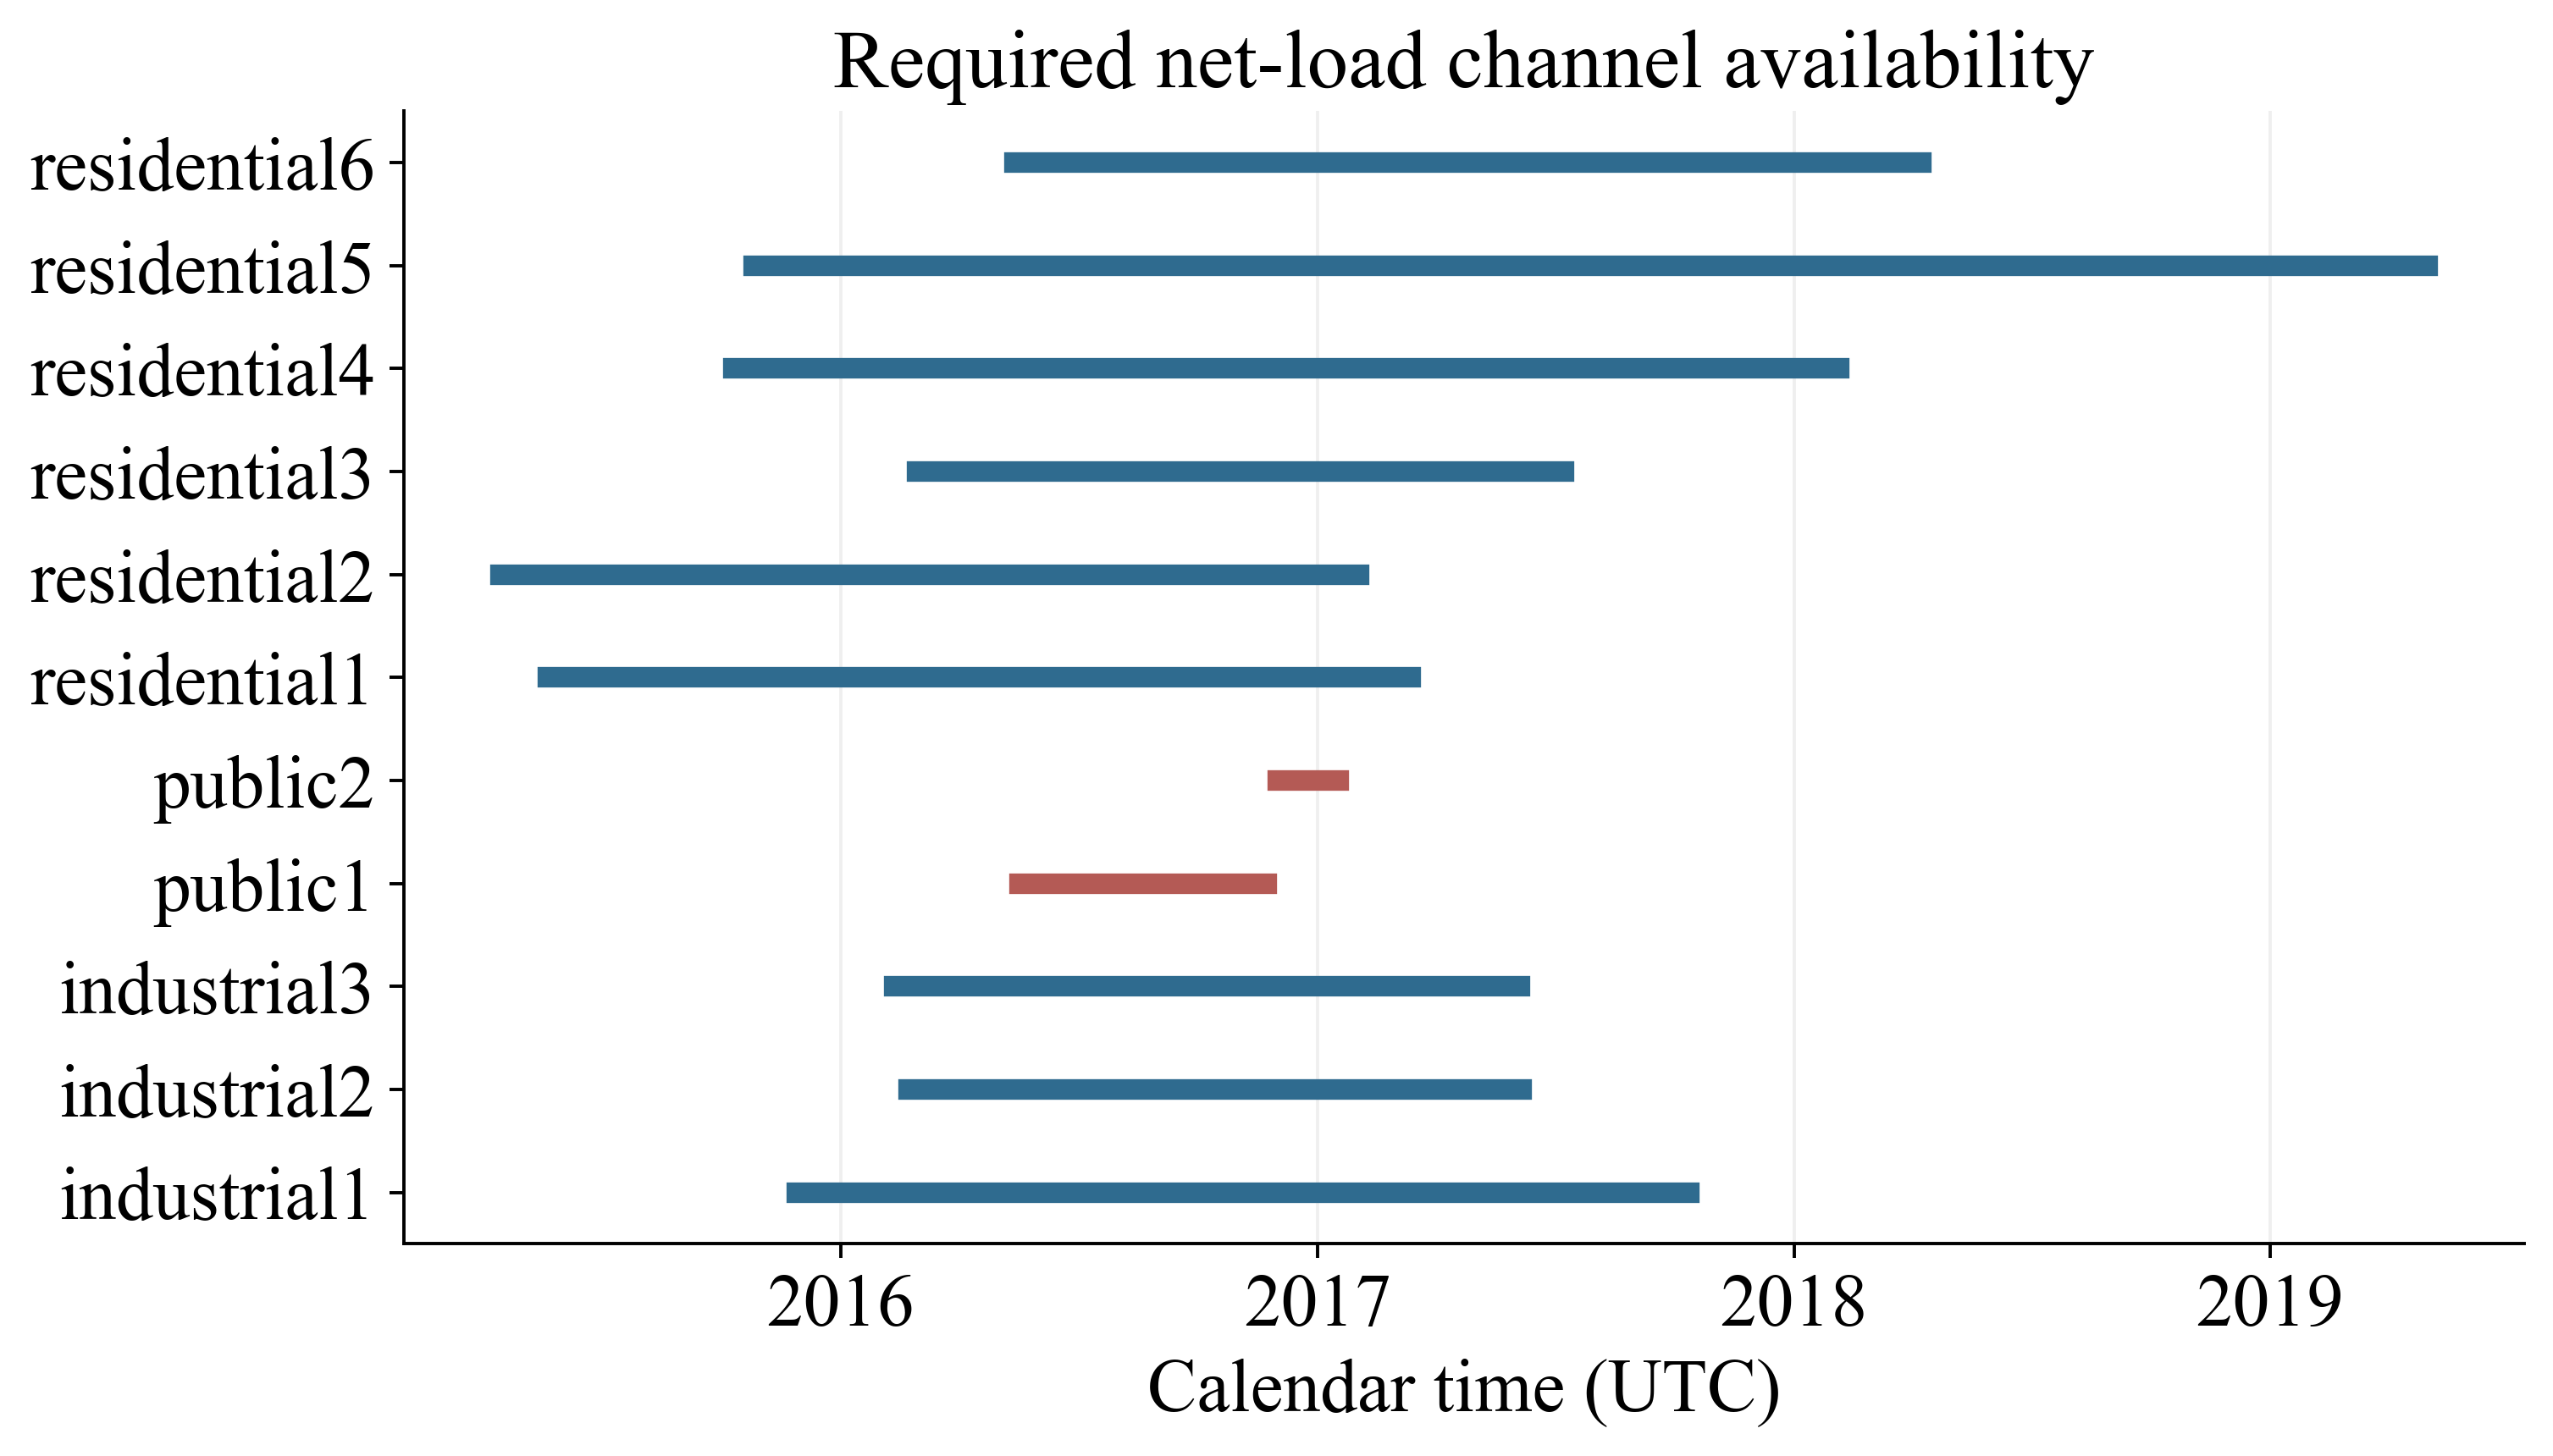

In [10]:
coverage=pd.read_csv(TABLE_DIR/'common_calendar_site_coverage.csv',parse_dates=['start_utc','end_utc'])
fig, ax = plt.subplots(figsize=(8.5, 4.8),layout='constrained')
for i,row in coverage.iterrows():
    ax.plot([row.start_utc,row.end_utc],[i,i],lw=5,color='#B45A55' if row.site.startswith('public') else '#2F6B8F')
ax.set_yticks(range(len(coverage)),coverage.site)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlabel('Calendar time (UTC)'); ax.set_title('Required net-load channel availability')
ax.grid(axis='x',alpha=.2)
for extension in ['png','pdf']:
    fig.savefig(FIGURE_DIR/f'revision_calendar_coverage.{extension}',dpi=350,bbox_inches='tight',pad_inches=.06)
plt.show()


## Recover original measurements
The official `make_equidistant()` interpolates short gaps before markers are constructed. Furthermore, 15-minute bins are left-labelled and use `.last()`, so their readings may be later than the nominal timestamp. We therefore read the original binary meter records. The 29 declared grid, PV, storage, EV and heat-pump feeds are retrieved directly from the official ZIP using HTTP ranges, checked with the ZIP CRC and recorded with SHA-256. No supplier interpolation or retrospective cleaning is executed.

Source: https://github.com/isc-konstanz/household_data/tree/2020-04-15

In [5]:
import urllib.request, struct, zlib, concurrent.futures
RAW_DIR = PROJECT_DIR/'.cache/experiment/raw'
RAW_DIR.mkdir(parents=True,exist_ok=True)
RAW_URL = 'https://data.open-power-system-data.org/household_data/2020-04-15/original_data/original_data.zip'
selected_feeds = json.loads((STATE_DIR/'raw_selected_feed_inventory.json').read_text())
def read_range(start, size):
    req = urllib.request.Request(RAW_URL,headers={'Range':f'bytes={start}-{start+size-1}'})
    with urllib.request.urlopen(req,timeout=120) as response:
        assert response.status == 206
        data = response.read()
    assert len(data)==size
    return data

def acquire_feed(item):
    path = RAW_DIR / item['site'] / (item['channel']+'.MYD')
    path.parent.mkdir(parents=True,exist_ok=True)
    if path.exists():
        data = path.read_bytes()
    else:
        header = read_range(item['offset'],30)
        fields = struct.unpack('<IHHHHHIIIHH',header)
        assert fields[0] == 0x04034b50 and fields[3] == 8
        start = item['offset'] + 30 + fields[-2] + fields[-1]
        compressed = read_range(start,item['compressed'])
        data = zlib.decompress(compressed,-15)
        assert len(data)==item['size'] and zlib.crc32(data)==item['crc']
        path.write_bytes(data)
    assert len(data)==item['size'] and zlib.crc32(data)==item['crc']
    return {**item,'local_path':str(path.relative_to(PROJECT_DIR)), 'sha256':hashlib.sha256(data).hexdigest()}

raw_manifest=[]
with concurrent.futures.ThreadPoolExecutor(max_workers=6) as pool:
    futures=[pool.submit(acquire_feed,item) for item in selected_feeds]
    for future in concurrent.futures.as_completed(futures):
        raw_manifest.append(future.result())
raw_manifest=pd.DataFrame(raw_manifest).sort_values(['site','channel'])
raw_manifest.to_csv(TABLE_DIR/'raw_meter_manifest.csv',index=False)
display(raw_manifest[['site','channel','size']])


,site,channel,size
16,industrial1,grid_import,6083631
19,industrial1,pv_1,2596914
17,industrial1,pv_2,2815092
26,industrial2,grid_import,5197491
18,industrial2,pv,4595373
23,industrial2,storage_charge,5040936
20,industrial2,storage_decharge,5041584
24,industrial3,ev,4573431
21,industrial3,grid_import,5396913
25,industrial3,pv_facade,5825565


In [8]:
from pathlib import Path
import sys
_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'dataset').is_dir() and (p / 'notebooks').is_dir())
if str(_root / 'notebooks') not in sys.path:
    sys.path.insert(0, str(_root / 'notebooks'))
from _runtime import (reuse as _nb_reuse, source_document as _source_document,
                      initialize, repo_root as _repo_root, result_tables,
                      result_state, plot_data, figure_stem)
initialize()

from pathlib import Path
import json, hashlib, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import colors as mcolors
from matplotlib.text import Text
from matplotlib.ticker import FuncFormatter
from matplotlib.font_manager import findfont, FontProperties
from matplotlib.patches import FancyBboxPatch
from IPython.display import display, Image
PROJECT_DIR=_repo_root()
TABLE_DIR=result_tables(); FIGURE_DIR=PROJECT_DIR/'.cache/experiment/figures'; STATE_DIR=result_state()
VISUAL_DATA=plot_data()
protocol=json.loads((STATE_DIR/'experiment_config.json').read_text())
plt.rcParams.update({'font.family':'Times New Roman','font.size':18,'axes.titlesize':20,'axes.labelsize':18,'xtick.labelsize':18,'ytick.labelsize':18,'legend.fontsize':18,'figure.titlesize':20,'figure.dpi':350,'savefig.dpi':350,'pdf.fonttype':42,'ps.fonttype':42,'axes.unicode_minus':True,'axes.spines.top':False,'axes.spines.right':False})
assert Path(findfont(FontProperties(family='Times New Roman'),fallback_to_default=False)).exists()
C={'blue':'#356E95','orange':'#C35232','green':'#2F8067','purple':'#8464A2','gray':'#596572','gold':'#A77722'}
def save_figure(fig,stem,data):
    """Formatting/export only: scientific data construction remains in each cell."""
    # Plain numeric log ticks keep every PDF glyph at 18 pt, including exponents.
    def scientific_tick(value: float, position: int) -> str:
        label = f'{value:.0e}'.replace('e+0', 'e').replace('e+', 'e') if abs(value) >= 10000 else f'{value:g}'
        return label.replace('-', '−')
    for axes in fig.axes:
        for axis in (axes.xaxis, axes.yaxis):
            if axis.get_scale() in ('log', 'symlog'):
                axis.set_major_formatter(FuncFormatter(scientific_tick))
    fig.canvas.draw()
    for text in fig.findobj(Text):
        if text.get_visible() and text.get_text():
            text.set_fontfamily('Times New Roman')
            assert 18-1e-6 <= text.get_fontsize() <= 20+1e-6,(stem,text.get_text(),text.get_fontsize())
    stem=figure_stem(stem)
    paths={ext:FIGURE_DIR/f'{stem}.{ext}' for ext in ['png','pdf']}
    for ext,path in paths.items():fig.savefig(path,dpi=350,bbox_inches='tight',pad_inches=.06,facecolor='white')
    # Rendering is read-only with respect to the frozen numerical results.
    plt.close(fig)
    display(Image(filename=str(paths['png']),width=min(1040,round(fig.get_figwidth()*105))))
def panel_letters(axes):
    """Place a panel identifier below its x-axis caption without shrinking type."""
    for index, axis in enumerate(np.asarray(axes, dtype=object).ravel()):
        caption = axis.get_xlabel()
        axis.set_xlabel(f"{caption}\n({chr(97 + index)})" if caption else f"({chr(97 + index)})",
                        fontsize=18, linespacing=1.1)

def labelled_matrix(ax,frame,title,fmt='.2f',cmap='viridis',vmin=None,vmax=None,cbar_label=''):
    a=frame.to_numpy(dtype=float)
    im=ax.imshow(np.ma.masked_invalid(a),cmap=cmap,vmin=vmin,vmax=vmax,aspect='auto')
    ax.set(xticks=np.arange(len(frame.columns)),xticklabels=frame.columns,yticks=np.arange(len(frame)),yticklabels=frame.index,title=title)
    ax.tick_params(axis='x',rotation=40)
    for tick in ax.get_xticklabels():tick.set_ha('right')
    for (i,j),v in np.ndenumerate(a):
        if np.isfinite(v):
            r,g,b,_=im.cmap(im.norm(v));lum=.2126*r+.7152*g+.0722*b
            ax.text(j,i,format(v,fmt).replace('-', '−'),ha='center',va='center',fontsize=18,color='black' if lum>.55 else 'white')
        else:ax.text(j,i,'n/a',ha='center',va='center',fontsize=18,color='black')
    if cbar_label:ax.figure.colorbar(im,ax=ax,pad=.02).set_label(cbar_label)
    return im
def outside_legend(fig,ax,columns=3):
    handles,labels=ax.get_legend_handles_labels()
    fig.legend(handles,labels,loc='outside lower center',ncol=columns,frameon=False)


## Training net load and PV relationship

Source: `modeling_dataset.parquet`, train split; no supplier-filled targets.

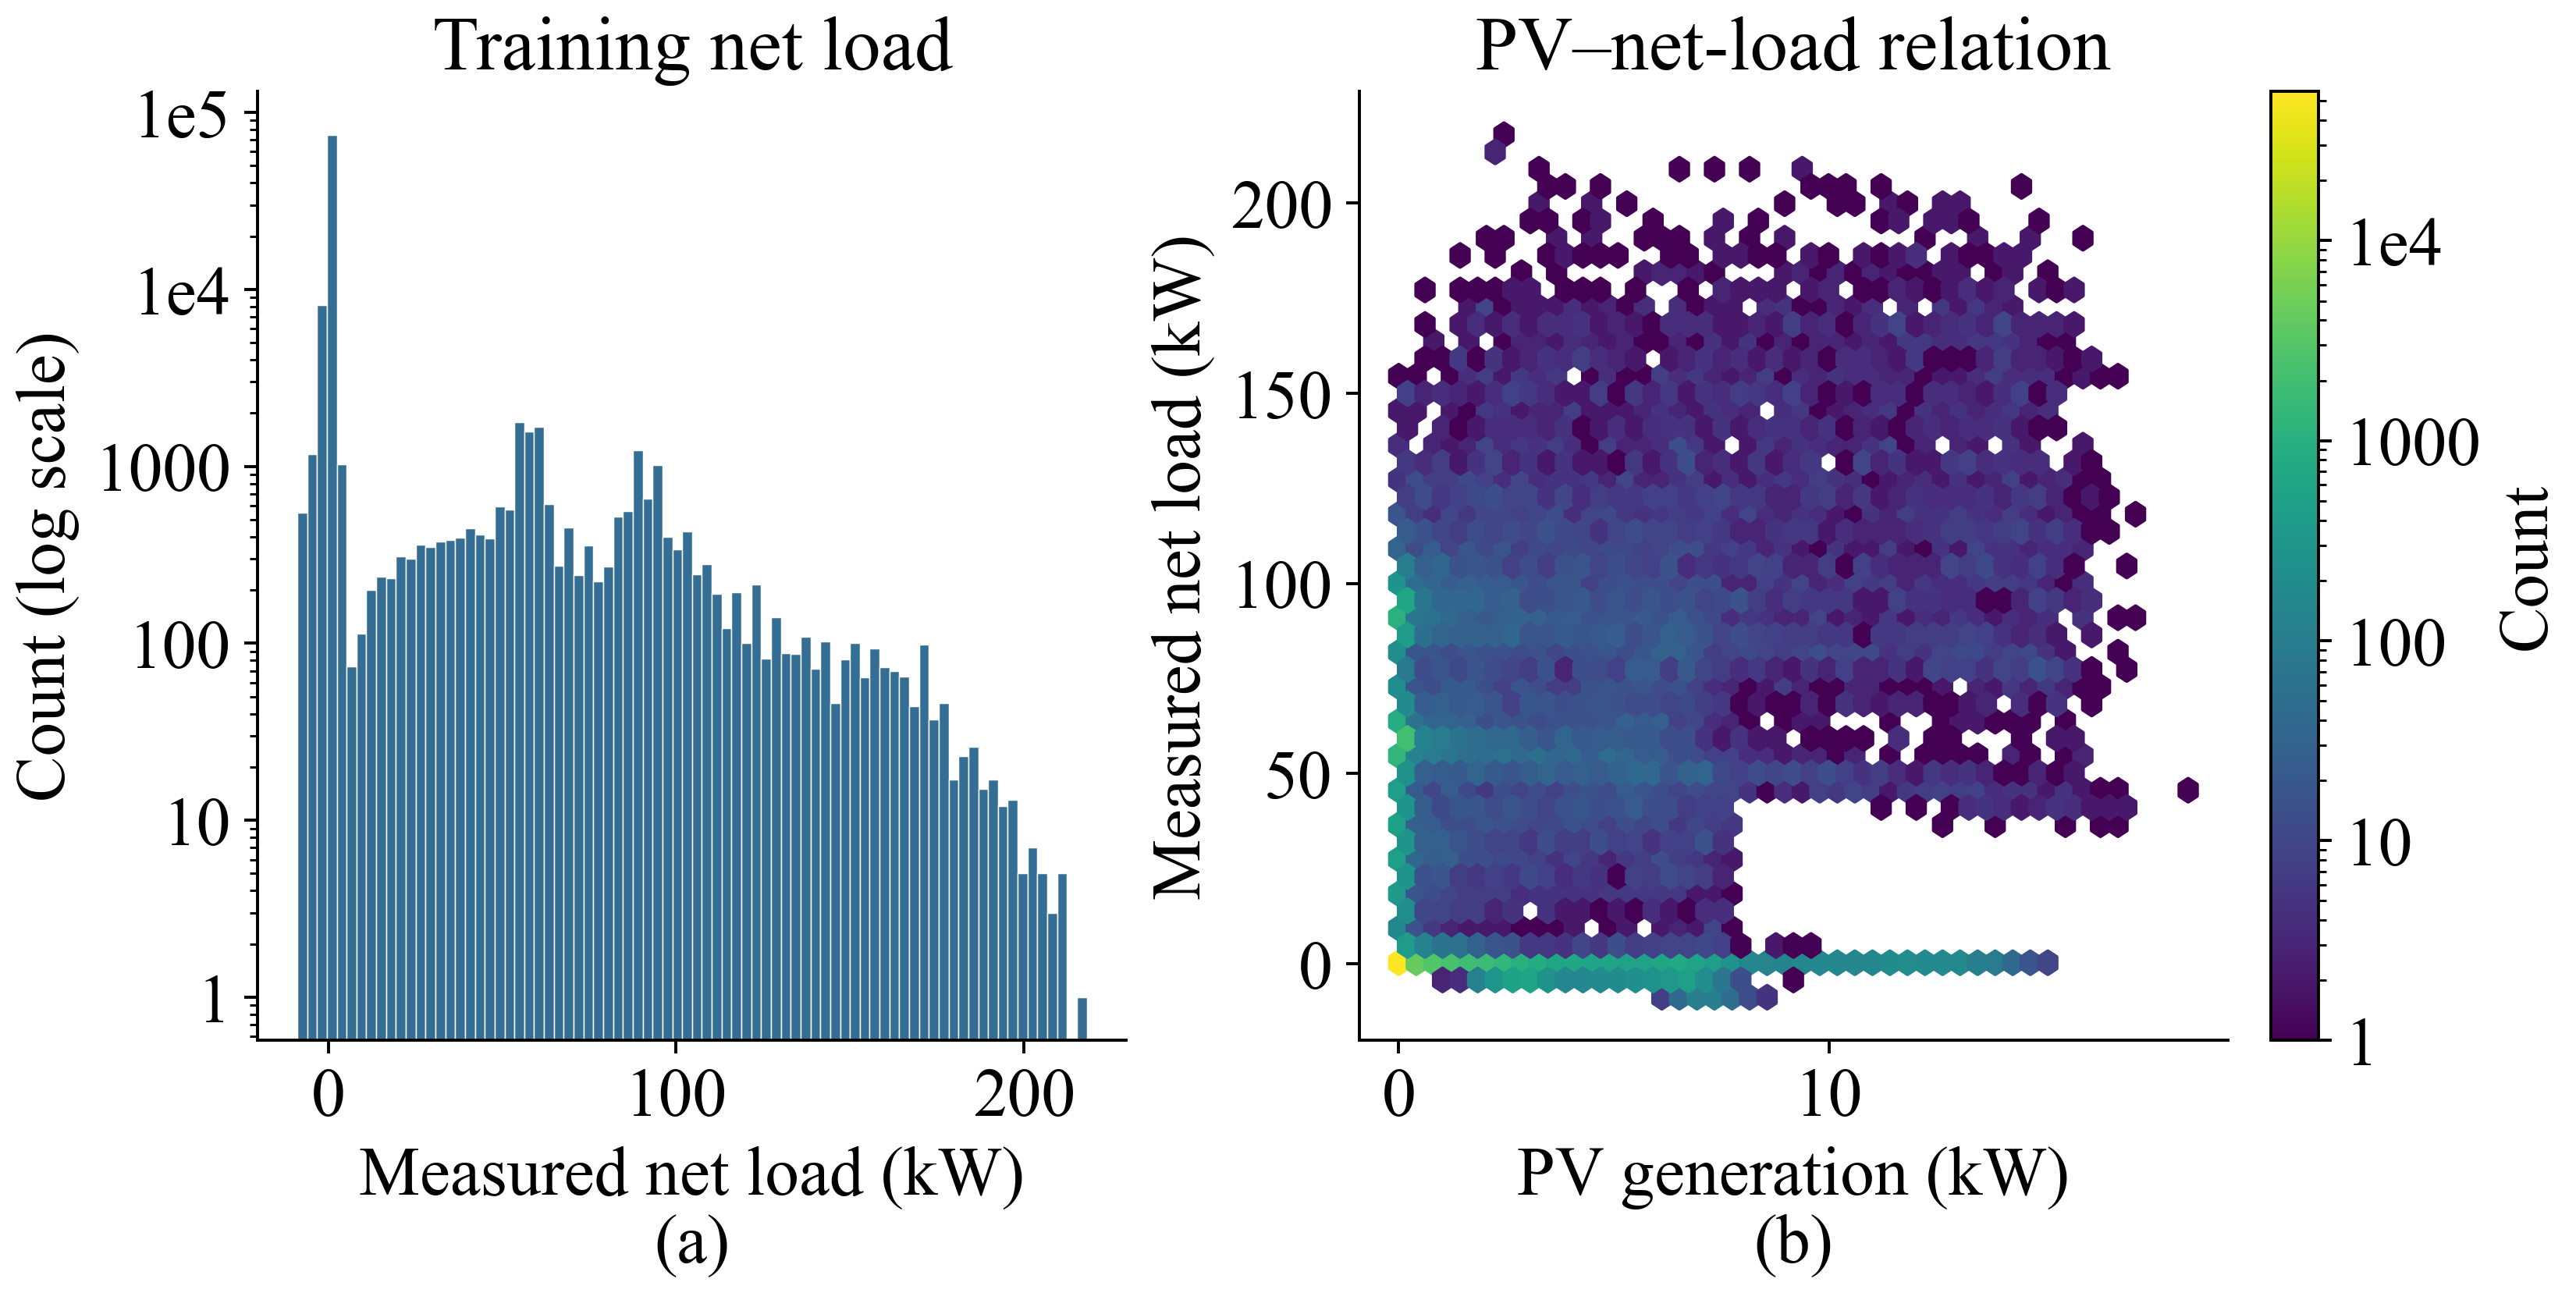

In [9]:
d=pd.read_csv(VISUAL_DATA/'revision_net_load_distribution_pv.csv',index_col=0)
fig,axes=plt.subplots(1,2,figsize=(9.4, 4.7),layout='constrained')
axes[0].hist(d.net_load_kw,bins=80,color=C['blue'],edgecolor='white',linewidth=.3)
axes[0].set(yscale='log',xlabel='Measured net load (kW)',ylabel='Count (log scale)',title='Training net load')
im=axes[1].hexbin(d.pv_power_kw,d.net_load_kw,gridsize=45,mincnt=1,bins='log',cmap='viridis')
axes[1].set(xlabel='PV generation (kW)',ylabel='Measured net load (kW)',title='PV–net-load relation')
fig.colorbar(im,ax=axes[1]).set_label('Count')
panel_letters(axes);save_figure(fig,'revision_net_load_distribution_pv',d)


The plots use the nine-site primary training period. Net load is a measurement-derived rate between asynchronous cumulative snapshots. The full observed range is shown; negative values denote net export.